In [1]:
import pandas as pd

**Data set exploration**

In [2]:
columns = ['Variance', 'Skewness', 'Curtosis', 'Entropy', 'Class']

In [3]:
df = pd.read_csv(
    "/content/banknote+authentication.zip",
    header=None,
    names=columns
)

In [4]:
df.head()

,Variance,Skewness,Curtosis,Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [5]:
print("The shape of the dataset is :",df.shape)

The shape of the dataset is : (1372, 5)


In [6]:
print("Missing Values")
df.isnull().sum()

Missing Values


,0
Variance,0
Skewness,0
Curtosis,0
Entropy,0
Class,0


In [7]:
print("Describe")
df.info()

Describe
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Variance  1372 non-null   float64
 1   Skewness  1372 non-null   float64
 2   Curtosis  1372 non-null   float64
 3   Entropy   1372 non-null   float64
 4   Class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


In [8]:
df.describe()

,Variance,Skewness,Curtosis,Entropy,Class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


**Exploratory Data Analysis**

In [9]:
import os

os.makedirs("plots", exist_ok=True)

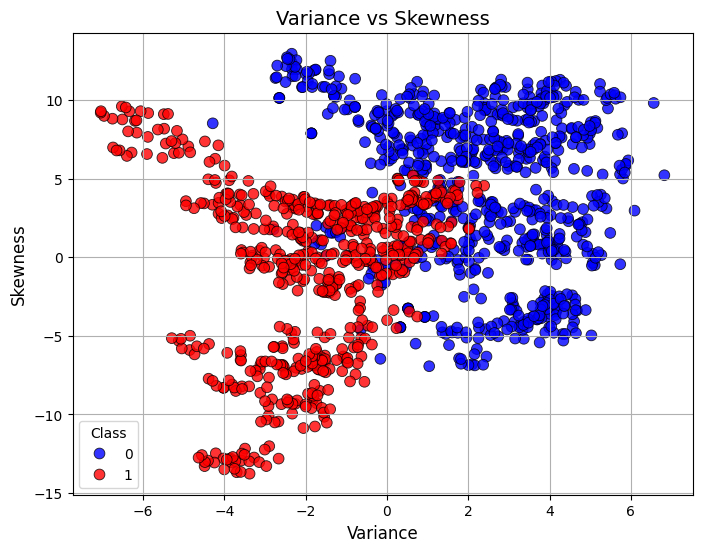

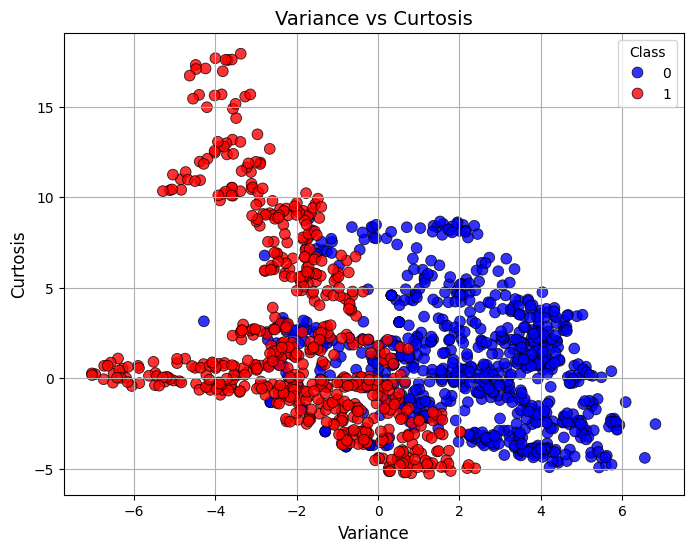

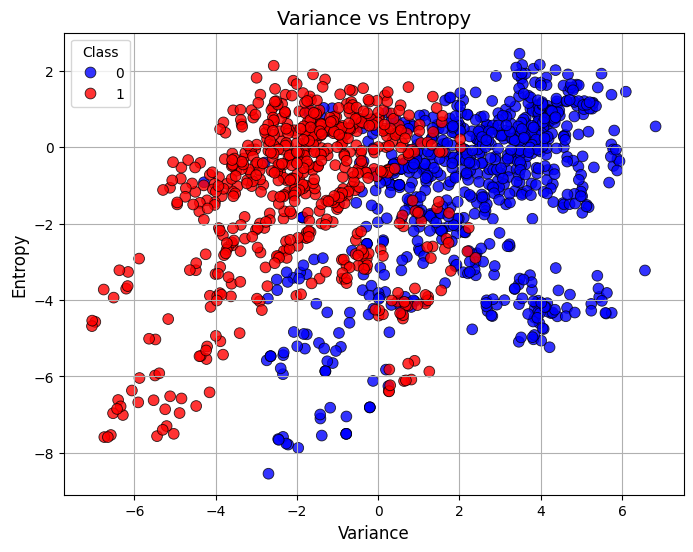

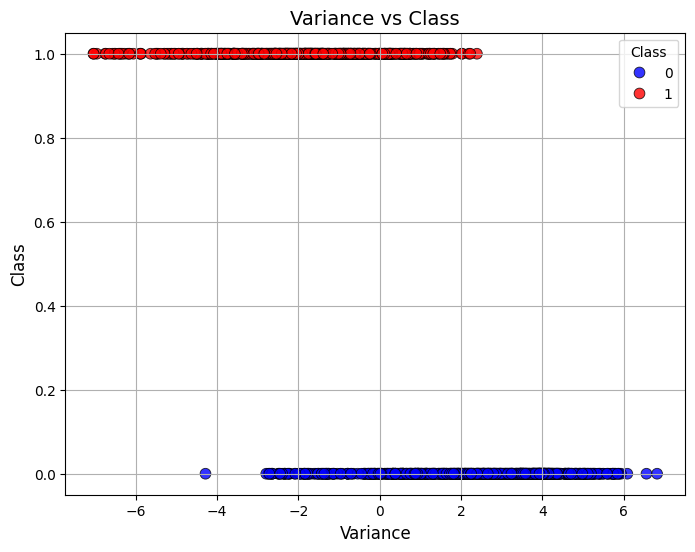

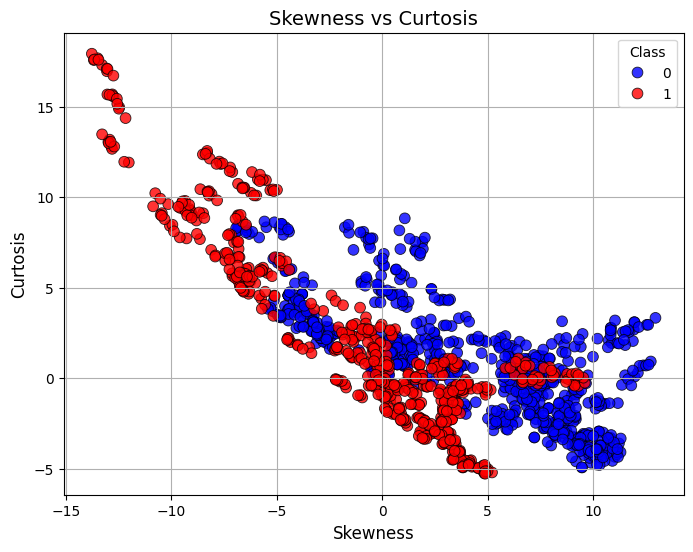

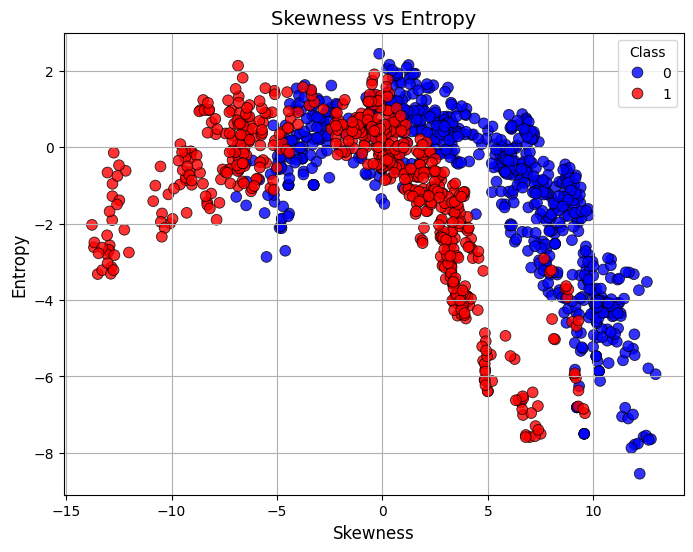

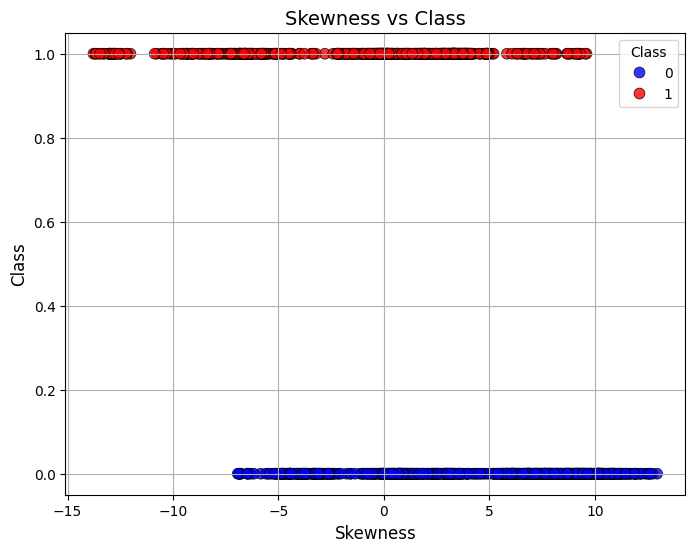

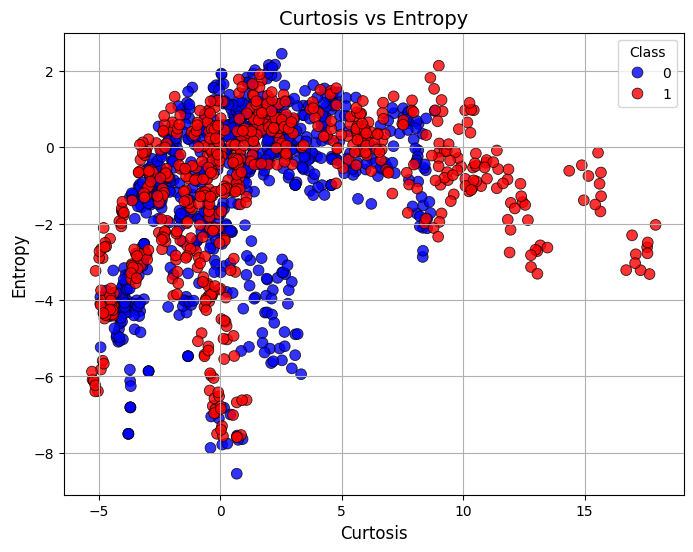

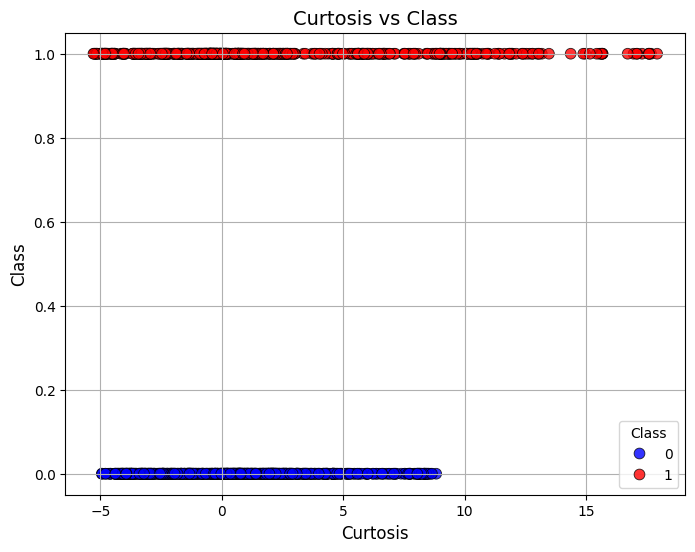

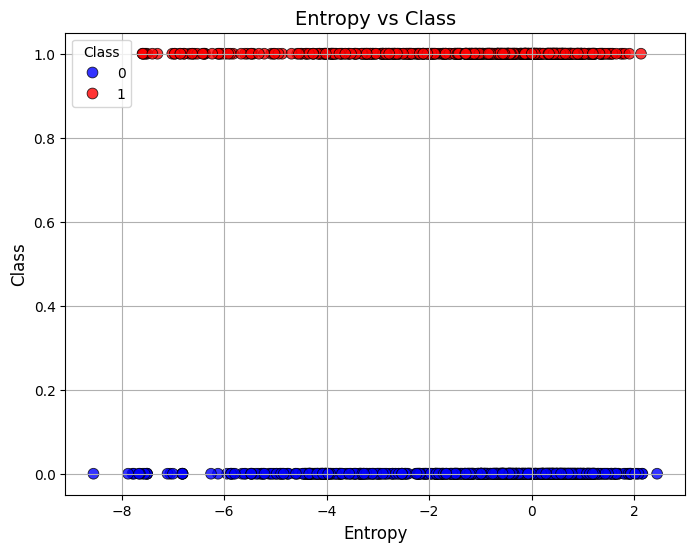

In [10]:
import itertools
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Generate all pairwise combinations
feature_pairs = list(itertools.combinations(columns, 2))

for feature_x, feature_y in feature_pairs:

    plt.figure(figsize=(8, 6))

    sns.scatterplot(
        data=df,
        x=feature_x,
        y=feature_y,
        hue="Class",
        palette={0: "blue", 1: "red"},
        s=60,
        edgecolor="black",
        alpha=0.8
    )

    plt.title(f"{feature_x} vs {feature_y}", fontsize=14)
    plt.xlabel(feature_x, fontsize=12)
    plt.ylabel(feature_y, fontsize=12)
    plt.legend(title="Class")
    plt.grid(True)

    # Save as EPS (600 DPI)
    filename = f"plots/{feature_x}_{feature_y}.eps".replace(" ", "_")

    plt.savefig(
        filename,
        format="eps",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()

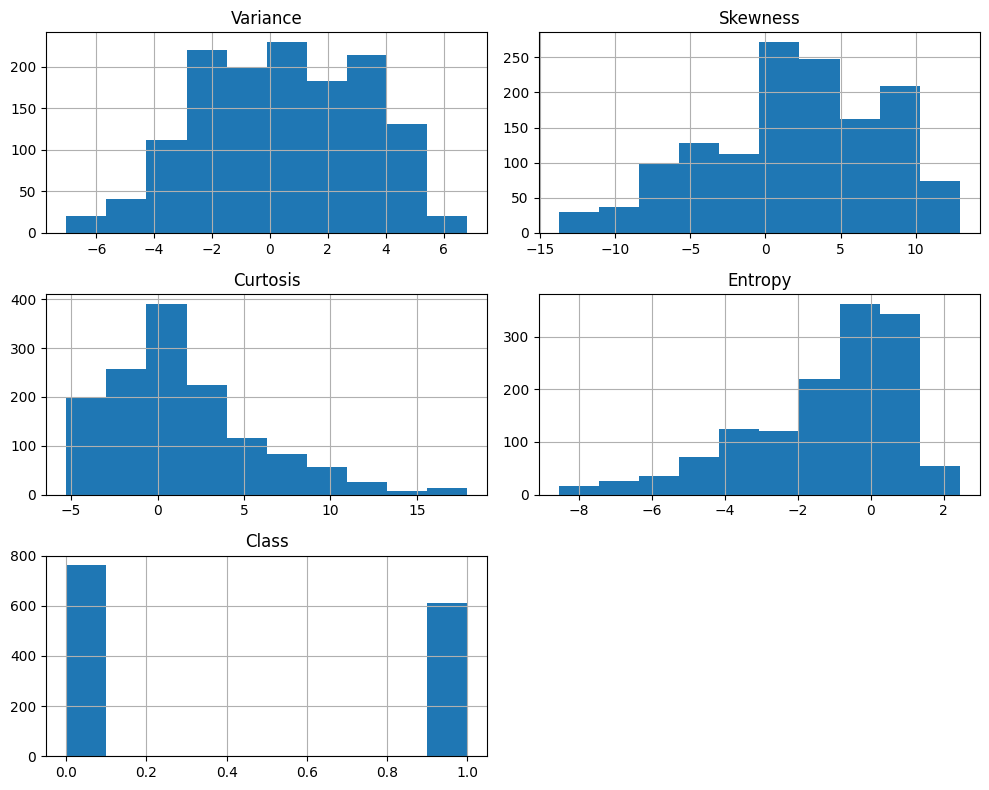

In [11]:
df.hist(figsize=(10,8))

plt.tight_layout()

plt.savefig(
    "plots/histogram.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

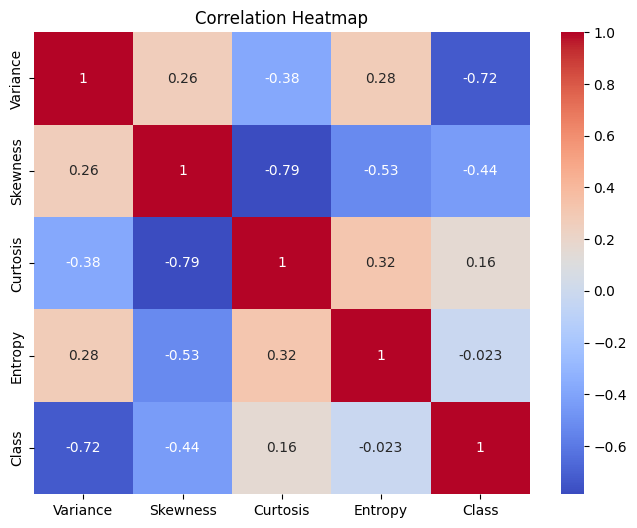

In [12]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig(
    "plots/correlation_heatmap.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

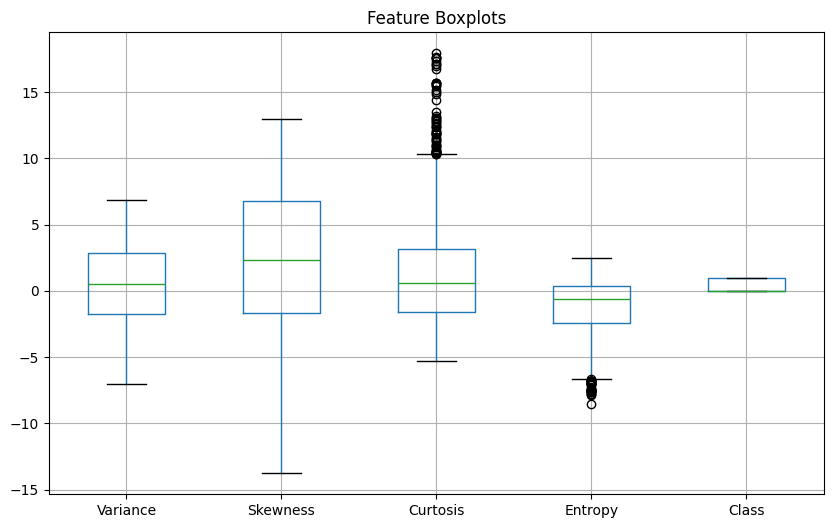

In [13]:
plt.figure(figsize=(10,6))

df.boxplot()

plt.title("Feature Boxplots")

plt.savefig(
    "plots/boxplot.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

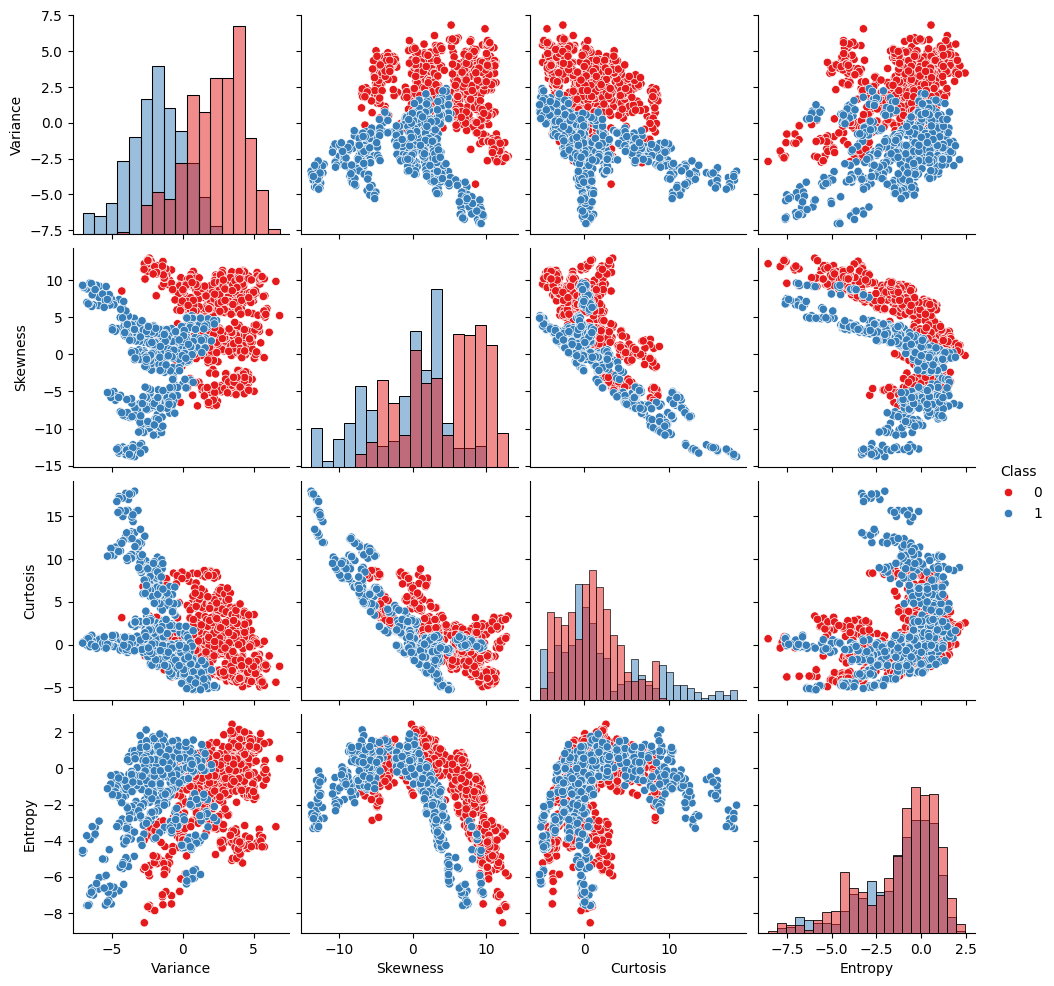

In [14]:
g = sns.pairplot(
    df,
    hue="Class",
    diag_kind="hist",
    palette="Set1"
)

g.savefig(
    "plots/pairplot.eps",
    dpi=600,
    format="eps",
    bbox_inches="tight"
)

plt.show()

In [15]:
X = df.iloc[:, :-1].values
Y = df.iloc[:, -1].values


In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

**Perceptron From Scratch**

In [18]:
import numpy as np

In [21]:
import numpy as np

class MyPerceptron:

    def __init__(self, learning_rate=0.01, epochs=50):
        self.lr = learning_rate
        self.epochs = epochs

    def initialize_weights(self, n_features):
        self.weights = np.zeros(n_features)
        self.bias = 0.0

    def activation(self, z):
        return 1 if z >= 0 else 0

    def forward(self, x):
        return np.dot(x, self.weights) + self.bias

    def predict_single(self, x):
        return self.activation(self.forward(x))

    def update_weights(self, x, actual, predicted):
        # Perceptron update rule
        update = self.lr * (actual - predicted)

        # Update weights
        self.weights += update * x

        # Update bias
        self.bias += update

    def fit(self, X, y):

        samples, features = X.shape

        # Initialize parameters
        self.initialize_weights(features)

        # Store training history
        self.errors = []
        self.weight_history = []
        self.bias_history = []

        print("=" * 100)
        print("PERCEPTRON TRAINING")
        print("=" * 100)

        for epoch in range(self.epochs):

            errors = 0

            # Iterate through all training samples
            for i in range(samples):

                prediction = self.predict_single(X[i])

                # Update only if prediction is wrong
                if prediction != y[i]:

                    self.update_weights(
                        X[i],
                        y[i],
                        prediction
                    )

                    errors += 1

            # Save history
            self.errors.append(errors)
            self.weight_history.append(self.weights.copy())
            self.bias_history.append(self.bias)

            # Display epoch details
            print("\n")
            print("-" * 80)
            print(f"Epoch : {epoch + 1}")
            print("-" * 80)

            print(f"Misclassified Samples : {errors}")

            print("\nUpdated Weights")
            for j in range(features):
                print(f"Weight {j+1} : {self.weights[j]:.6f}")

            print(f"\nUpdated Bias : {self.bias:.6f}")

            # Stop if perfectly classified
            if errors == 0:
                print("\nTraining Converged.")
                break

        print("\nTraining Completed Successfully.")

    def predict(self, X):
        return np.array([self.predict_single(x) for x in X])

Traning the model

In [22]:
model = MyPerceptron(
    learning_rate=0.01,
    epochs=50
)

model.fit(X_train, Y_train)

PERCEPTRON TRAINING


--------------------------------------------------------------------------------
Epoch : 1
--------------------------------------------------------------------------------
Misclassified Samples : 47

Updated Weights
Weight 1 : -0.072537
Weight 2 : -0.064863
Weight 3 : -0.064460
Weight 4 : 0.000199

Updated Bias : -0.030000


--------------------------------------------------------------------------------
Epoch : 2
--------------------------------------------------------------------------------
Misclassified Samples : 26

Updated Weights
Weight 1 : -0.082170
Weight 2 : -0.093802
Weight 3 : -0.051494
Weight 4 : -0.005182

Updated Bias : -0.030000


--------------------------------------------------------------------------------
Epoch : 3
--------------------------------------------------------------------------------
Misclassified Samples : 34

Updated Weights
Weight 1 : -0.094676
Weight 2 : -0.091400
Weight 3 : -0.089055
Weight 4 : -0.009565

Updated Bias : -0.0500

In [23]:

print("TRAINING SUMMARY")


print(f"Learning Rate      : {model.lr}")
print(f"Epochs Completed   : {len(model.errors)}")
print(f"Final Errors       : {model.errors[-1]}")

print("\nFinal Weights")

for i, weight in enumerate(model.weights):
    print(f"Weight {i+1} : {weight:.6f}")

print(f"\nFinal Bias : {model.bias:.6f}")

TRAINING SUMMARY
Learning Rate      : 0.01
Epochs Completed   : 50
Final Errors       : 13

Final Weights
Weight 1 : -0.196595
Weight 2 : -0.219351
Weight 3 : -0.210659
Weight 4 : -0.018478

Final Bias : -0.100000


In [24]:
import pandas as pd

history = pd.DataFrame({

    "Epoch": np.arange(1, len(model.errors)+1),

    "Misclassified Samples": model.errors,

    "Weight1": [w[0] for w in model.weight_history],

    "Weight2": [w[1] for w in model.weight_history],

    "Weight3": [w[2] for w in model.weight_history],

    "Weight4": [w[3] for w in model.weight_history],

    "Bias": model.bias_history

})

print(history)

    Epoch  Misclassified Samples   Weight1   Weight2   Weight3   Weight4  Bias
0       1                     47 -0.072537 -0.064863 -0.064460  0.000199 -0.03
1       2                     26 -0.082170 -0.093802 -0.051494 -0.005182 -0.03
2       3                     34 -0.094676 -0.091400 -0.089055 -0.009565 -0.05
3       4                     23 -0.110745 -0.095809 -0.106307 -0.013124 -0.04
4       5                     27 -0.130964 -0.121796 -0.091128 -0.008771 -0.05
5       6                     25 -0.139534 -0.128430 -0.104882 -0.006691 -0.04
6       7                     19 -0.135270 -0.140369 -0.105269 -0.005157 -0.05
7       8                     19 -0.133463 -0.144820 -0.104906  0.001333 -0.06
8       9                     16 -0.134315 -0.131837 -0.123976 -0.011640 -0.06
9      10                     26 -0.131687 -0.155810 -0.126006  0.011535 -0.06
10     11                     25 -0.134304 -0.163344 -0.123422  0.004369 -0.07
11     12                     26 -0.134814 -0.172105

In [25]:
# -------------------------------------------
# Task 6.1 : Predict Test Data
# -------------------------------------------

y_pred = []

for sample in X_test:
    prediction = model.predict_single(sample)
    y_pred.append(prediction)

y_pred = np.array(y_pred)

In [26]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [27]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.linear_model import Perceptron
accuracy = accuracy_score(Y_test, y_pred)

precision = precision_score(Y_test, y_pred)

recall = recall_score(Y_test, y_pred)

f1 = f1_score(Y_test, y_pred)

print("="*60)
print("MODEL PERFORMANCE")
print("="*60)

print(f"Accuracy  : {accuracy}")

print(f"Precision : {precision}")

print(f"Recall    : {recall}")

print(f"F1 Score  : {f1:}")

MODEL PERFORMANCE
Accuracy  : 0.9781818181818182
Precision : 0.984
Recall    : 0.968503937007874
F1 Score  : 0.9761904761904762


In [28]:
print("\nClassification Report\n")

print(classification_report(Y_test, y_pred))


Classification Report

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       148
           1       0.98      0.97      0.98       127

    accuracy                           0.98       275
   macro avg       0.98      0.98      0.98       275
weighted avg       0.98      0.98      0.98       275



In [29]:
cm = confusion_matrix(Y_test, y_pred)

print("\nConfusion Matrix\n")

print(cm)


Confusion Matrix

[[146   2]
 [  4 123]]


In [30]:
import os

os.makedirs("plots1", exist_ok=True)

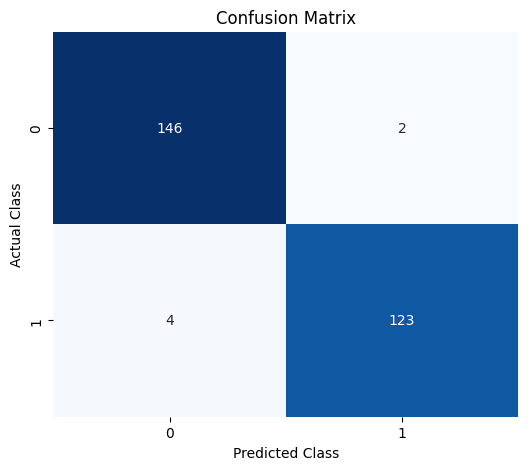

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d",
    cbar=False
)

plt.xlabel("Predicted Class")

plt.ylabel("Actual Class")

plt.title("Confusion Matrix")

plt.savefig(
    "plots1/confusion_matrix.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [34]:
performance = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Value":[
        accuracy,
        precision,
        recall,
        f1
    ]

})

print(performance)

performance.to_csv(
    "Performance_Table.csv",
    index=False
)

      Metric     Value
0   Accuracy  0.978182
1  Precision  0.984000
2     Recall  0.968504
3   F1 Score  0.976190


Task 7

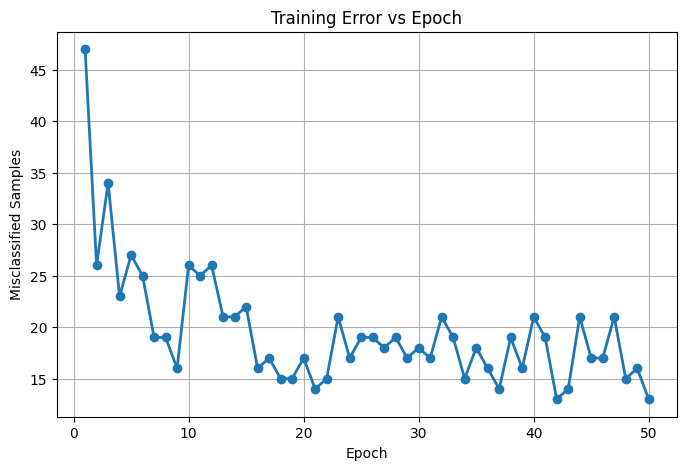

In [35]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,len(model.errors)+1),
    model.errors,
    marker='o',
    linewidth=2
)

plt.xlabel("Epoch")

plt.ylabel("Misclassified Samples")

plt.title("Training Error vs Epoch")

plt.grid(True)

plt.savefig(
    "plots1/training_error.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

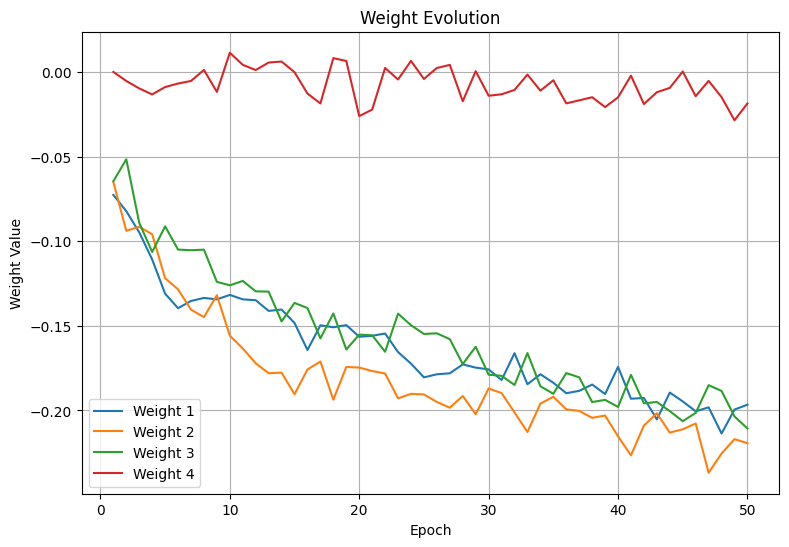

In [36]:
weights = np.array(model.weight_history)

plt.figure(figsize=(9,6))

for i in range(weights.shape[1]):

    plt.plot(
        range(1,len(model.weight_history)+1),
        weights[:,i],
        label=f"Weight {i+1}"
    )

plt.xlabel("Epoch")

plt.ylabel("Weight Value")

plt.title("Weight Evolution")

plt.legend()

plt.grid(True)

plt.savefig(
    "plots1/weight_evolution.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

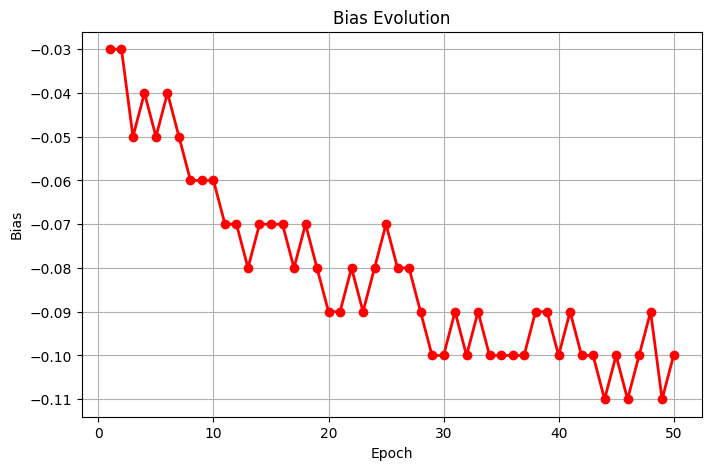

In [37]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,len(model.bias_history)+1),
    model.bias_history,
    marker='o',
    linewidth=2,
    color='red'
)

plt.xlabel("Epoch")

plt.ylabel("Bias")

plt.title("Bias Evolution")

plt.grid(True)

plt.savefig(
    "plots1/bias_evolution.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

PERCEPTRON TRAINING


--------------------------------------------------------------------------------
Epoch : 1
--------------------------------------------------------------------------------
Misclassified Samples : 47

Updated Weights
Weight 1 : -0.007254
Weight 2 : -0.006486
Weight 3 : -0.006446
Weight 4 : 0.000020

Updated Bias : -0.003000


--------------------------------------------------------------------------------
Epoch : 2
--------------------------------------------------------------------------------
Misclassified Samples : 26

Updated Weights
Weight 1 : -0.008217
Weight 2 : -0.009380
Weight 3 : -0.005149
Weight 4 : -0.000518

Updated Bias : -0.003000


--------------------------------------------------------------------------------
Epoch : 3
--------------------------------------------------------------------------------
Misclassified Samples : 34

Updated Weights
Weight 1 : -0.009468
Weight 2 : -0.009140
Weight 3 : -0.008906
Weight 4 : -0.000956

Updated Bias : -0.0050

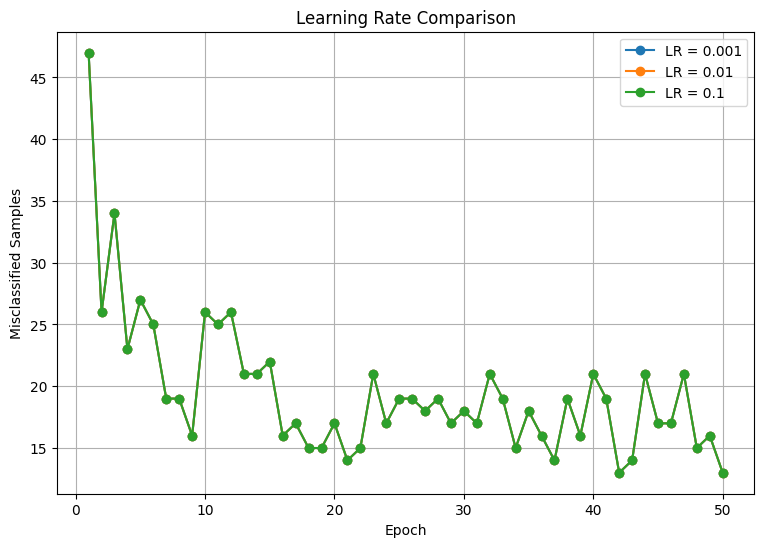

In [38]:
learning_rates = [0.001,0.01,0.1]

plt.figure(figsize=(9,6))

for lr in learning_rates:

    temp_model = MyPerceptron(
        learning_rate=lr,
        epochs=50
    )

    temp_model.fit(X_train,Y_train)

    plt.plot(
        range(1,len(temp_model.errors)+1),
        temp_model.errors,
        marker='o',
        label=f"LR = {lr}"
    )

plt.xlabel("Epoch")

plt.ylabel("Misclassified Samples")

plt.title("Learning Rate Comparison")

plt.legend()

plt.grid(True)

plt.savefig(
    "plots1/learning_rate_comparison.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [39]:
print("\n")
print("="*120)
print("EPOCH-WISE LEARNING")
print("="*120)

print("{:<8}{:<10}{:<12}{:<12}{:<12}{:<12}{:<12}".format(
    "Epoch",
    "Errors",
    "Weight1",
    "Weight2",
    "Weight3",
    "Weight4",
    "Bias"
))

for i in range(len(model.errors)):

    w = model.weight_history[i]

    print("{:<8}{:<10}{:<12.5f}{:<12.5f}{:<12.5f}{:<12.5f}{:<12.5f}".format(
        i+1,
        model.errors[i],
        w[0],
        w[1],
        w[2],
        w[3],
        model.bias_history[i]
    ))



EPOCH-WISE LEARNING
Epoch   Errors    Weight1     Weight2     Weight3     Weight4     Bias        
1       47        -0.07254    -0.06486    -0.06446    0.00020     -0.03000    
2       26        -0.08217    -0.09380    -0.05149    -0.00518    -0.03000    
3       34        -0.09468    -0.09140    -0.08906    -0.00956    -0.05000    
4       23        -0.11074    -0.09581    -0.10631    -0.01312    -0.04000    
5       27        -0.13096    -0.12180    -0.09113    -0.00877    -0.05000    
6       25        -0.13953    -0.12843    -0.10488    -0.00669    -0.04000    
7       19        -0.13527    -0.14037    -0.10527    -0.00516    -0.05000    
8       19        -0.13346    -0.14482    -0.10491    0.00133     -0.06000    
9       16        -0.13432    -0.13184    -0.12398    -0.01164    -0.06000    
10      26        -0.13169    -0.15581    -0.12601    0.01153     -0.06000    
11      25        -0.13430    -0.16334    -0.12342    0.00437     -0.07000    
12      26        -0.13481    